<h1 style="text-align:center;">Deep BSDE : scheme DBDP1</h1>

*Sources* : 
- [Deep backward schemes for high-dimensional nonlinear PDEs](https://arxiv.org/pdf/1902.01599)

*context* : In this project, we will pursue the BSDE original with the scheme DBDP1.

## Sumary :

* [**1.Introduction**](#0)
    * [1.1.Stock dynamics](#0_1)
    * [1.2.Construction of BSDE Scheme](#0_2)
    * [1.3.Euler Scheme of BSDE dymamics](#0_3)
    * [1.4.Neural network approximation of the process $(Y_t, Z_t)_{t \ge 0}$](#0_4)
    * [1.5.Loss function](#0_5)
* [**2.Application**](#1)
    * [2.1. NN architecture](#1_1)
    * [2.2. DBDP1 Scheme](#1_2)

* [**3. Validation**](#2)

* [**4. Appendix**](#3)
    * [4.1 Construction of BSDE Scheme](#3_1)
    * [4.2. Neural network approximation of the process $(Y_t, Z_t)_{t \ge 0}$](#3_2)

<a id='0'></a>
# 1. Introduction :

In this project, we will apply Deep BSDE methodology for an European call :

$$
\boxed{C_0 = \mathbb{E}\!\left[ e^{-rT} (S_T - K)_+ \right]}
$$


---

### 1.1 Stock dynamics :

Let $(\Omega, \mathcal{F}, \mathbb{P})$ be a probability space, $(W_t)_{t \geq 0}$ a Brownian motion under $\mathbb{P}$, and $(S_t)_{t \geq 0}$ the stock price process.

Let $\mathbb{Q}$ be an equivalent probability measure to $\mathbb{P}$, called the **risk–neutral measure**.


Under $\mathbb{Q}$, the dynamics of $S_t$ are given by:  

$$
\frac{dS_t}{S_t} = r \, dt + \sigma \, dW_t,
$$

--- 


### 1.2 Construction of BSDE Scheme :

**Details :** [Appendix Construction of BSDE Scheme](#3_1)


We have :
$$
\boxed{
dY_t = f(Y_t)\,dt + Z_t\,dW_t,
\qquad
Y_T = (S_T-K)_+
}
$$

with : 

$$
Y_t = C(t,S_t),
\qquad
Z_t = \sigma S_t\,\partial_s C(t,S_t),
\qquad
f(y)=r\,y
$$


---

### 1.3 Euler Scheme of BSDE dynamics :

Let $0 = t_1 < \cdots < t_N = T$ be a time partition with $\Delta t = t_{i}-t_{i-1}$.


which yields the discrete scheme

$$
\boxed{
Y_{t_{i+1}}
=
Y_{t_{i}}
+
f(Y_{t_{i}})\,\Delta t
+
Z_{t_{i}}\,\Delta W_i
}
$$

with : $\Delta W_i = W_{t_{i}} - W_{t_{i-1}}, \qquad \Delta W_i \sim \mathcal N(0,\Delta t), \qquad Y_T = g(S_T)$



---

### 1.4 Neurals networks approximation of the processes $(Y_t, Z_t)_{t \ge 0}$

**Details :** [Appendix Construction of Neural Networks](#3_2)

We approximate the control processes $(Y_t)_{t \ge 0}$ and $(Z_t)_{t \ge 0}$ using a family of feedforward neural networks :

$$
Z_{t_i} \approx NN_i^1(t_i,S_{t_i};\theta_i)
\qquad
Y_{t_i} \approx NN_i^2(t_i,S_{t_i};\theta_i)
$$

--- 


### 1.5 Loss functions


We define the local loss function at time $t_i$:

$$
\boxed{
L_i(\theta)
=
\mathbb{E}\!\left[
\left|
\hat Y_{t_{i+1}}
-
\Big(
Y_{t_i}
+ f(Y_{t_i})\,\Delta t_i
+ Z_{t_i}\,\Delta W_i
\Big)
\right|^2
\right]
}
$$

The objective is to minimize this loss with respect to $\theta$ at each time step:
$$
\theta_i^* \in \arg\min_{\theta} L_i(\theta).
$$

The procedure is then iterated backward in time, starting from the terminal condition:
$$
\hat Y_{t_N}(x) = g(x) = (x-K)_+.
$$

In [1]:
# Modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp
import torch
from torch import nn
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
import copy

<a id='1'></a>
# 2. Application :


---

<a id='1_1'></a>
### 2.1 Neural Network Architecture

For each time step $t_i$, we define a feedforward neural network:

$$NN_i : \mathbb{R}^2 \rightarrow \mathbb{R}$$

which takes as input $(t_i, S_{t_i})$ and outputs the control process $Z_{t_i}$ / $Y_{t_i}$.

**Architecture :**
- Input layer : $\mathbb{R}^2 \rightarrow \mathbb{R}^{d}$ where $d$ is the hidden size
- Activation function : $\rho$ (ReLU by default)
- Output layer : $\mathbb{R}^{d} \rightarrow \mathbb{R}$

$$NN_i(x) = A_2 \circ \rho \circ A_1(x), \qquad x = (t_i, S_{t_i}) \in \mathbb{R}^2$$

where $A_\ell(x) = W_\ell x + b_\ell$ are affine transformations with learnable parameters $\theta_i = (W_\ell, b_\ell)_{\ell=1,2}$.

---

In [2]:
class NN(nn.Module):
    """
    Simple feedforward network
    Input  : (t, S) in R^2
    Output : scalar
    """
    def __init__(self, hidden_size: int, activation_function: str = "ReLU"):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, hidden_size),
            getattr(nn, activation_function)(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.network(x)

---

<a id='1_2'></a>
### 2.2 DBDP1 Scheme

---

<div style="display: flex; justify-content: center;">

<div style="
    border: 1.5px solid black;
    padding: 16px 20px;
    font-family: monospace;
    line-height: 1.5;
    width: 75%;
">

Input:
    Time grid (t₀, ..., t_N)
    Simulated states S_{t_i} and Brownian increments ΔW_{t_i}
    Terminal payoff g
    Neural networks Y_{t_i}(.;θ), Z_{t_i}(.;θ)

Initialize:
    Ŷ_{t_N}(S_{t_N}) = g(S_{t_N})

For i = N-1, ..., 0:

    1. Target:
           target = Ŷ_{t_{i+1}}(S_{t_{i+1}})
           if i = N-1:
               target = g(S_{t_N})

    2. Prediction:
           prediction =
               Y_{t_i}(S_{t_i};θ)
               + f(t_i, S_{t_i}, Y_{t_i}, Z_{t_i}) Δt_i
               + Z_{t_i}(S_{t_i};θ) ΔW_{t_i}

    3. Loss:
           L_i(θ) = E[ | target − prediction |² ]

    4. Update:
           Ŷ_{t_i}(.) = Y_{t_i}(.;θ_i*)
           Ẑ_{t_i}(.) = Z_{t_i}(.;θ_i*)

Return:
    Price = Ŷ_{t_0}(S_0)

</div>
</div>

---

##### Class Structure

| Function | Role |
|--------|------|
| `simulate_paths` | Generate $S_{t_k}$ and $\Delta W_k$ |
| `build_input` | Build $(t_k, S_{t_k})$ |
| `one_step_prediction` | Compute $\widehat{Y}_{t_{k+1}}$ |
| `compute_target` | Define $\text{target}_k$ |
| `local_loss` | Compute $L_k$ |
| `train_one_step` | Train $(Y_k, Z_k)$ |
| `train_model` | Backward training loop |
| `price` | Return $Y_0(0, S_0)$ |

---

In [3]:
class DBDP1(nn.Module):
    """
    Implementation of a DBDP1-type scheme in dimension 1.

    Main idea:
    - Y_k(t_k, S_k) approximates Y_k
    - Z_k(t_k, S_k) approximates Z_k
    - At each date k, we solve a local regression problem:
          target = Y_{k+1}(t_{k+1}, S_{k+1})   if k < N-1
                 = payoff(S_T)                 if k = N-1

          pred   = Y_k + f(Y_k) dt + Z_k dW
    """

    def __init__(
        self,
        N: int,
        n: int,
        S0: float,
        T: float,
        K: float,
        r: float,
        sigma: float,
        hidden_size: int,
        activation_function: str = "ReLU"
    ):
        super().__init__()

        self.N = N                  # number of time steps
        self.n = n                  # Monte Carlo batch size
        self.S0 = S0
        self.T = T
        self.K = K
        self.r = r
        self.sigma = sigma
        self.hidden_size = hidden_size
        self.delta_t = T / N

        # One pair of networks per time step k = 0, ..., N-1
        self.networks_Y = nn.ModuleList([
            NN(hidden_size, activation_function) for _ in range(N)
        ])
        self.networks_Z = nn.ModuleList([
            NN(hidden_size, activation_function) for _ in range(N)
        ])

        self.loss_history = []
        self.step_loss_history = {}

    # ------------------------------------------------------------------
    # Utility functions
    # ------------------------------------------------------------------
    def payoff(self, S):
        return torch.clamp(S - self.K, min=0.0)

    def simulate_paths(self):
        """
        Simulate one MC batch of Euler paths for the underlying.

        Returns
        -------
        S  : tensor of shape (n, N+1)
        dW : tensor of shape (n, N)
        """
        dW = torch.randn(self.n, self.N) * (self.delta_t ** 0.5)

        S = torch.zeros(self.n, self.N + 1)
        S[:, 0] = self.S0

        for k in range(self.N):
            S[:, k + 1] = (
                S[:, k]
                + self.r * S[:, k] * self.delta_t
                + self.sigma * S[:, k] * dW[:, k]
            )

        return S, dW

    def build_input(self, k, S_k):
        """
        Build input x_k = (t_k, S_k) of shape (n, 2)
        """
        t_k = torch.full((S_k.shape[0], 1), k * self.delta_t)
        S_k = S_k.unsqueeze(1)
        return torch.cat([t_k, S_k], dim=1)

    def one_step_prediction(self, k, S_k, dW_k):
        """
        Compute the local prediction of Y_{k+1} from time k:
            Y_{k+1}^pred = Y_k + r Y_k dt + Z_k dW_k
        """
        x_k = self.build_input(k, S_k)

        Y_k = self.networks_Y[k](x_k).squeeze(1)   # (n,)
        Z_k = self.networks_Z[k](x_k).squeeze(1)   # (n,)

        Y_pred = Y_k + self.r * Y_k * self.delta_t + Z_k * dW_k
        return Y_pred

    def local_loss(self, Y_target, Y_pred):
        return ((Y_target - Y_pred) ** 2).mean()

    # ------------------------------------------------------------------
    # Local target construction
    # ------------------------------------------------------------------
    def compute_target(self, k, S_next):
        """
        Return the local target for step k.

        If k = N-1:
            target = payoff(S_T)

        Else:
            target = U_{k+1}(t_{k+1}, S_{k+1}) evaluated with frozen next network
        """
        if k == self.N - 1:
            return self.payoff(S_next)

        with torch.no_grad():
            x_next = self.build_input(k + 1, S_next)
            target = self.networks_Y[k + 1](x_next).squeeze(1)

        return target

    # ------------------------------------------------------------------
    # Warm start
    # ------------------------------------------------------------------
    def copy_weights(self, source_k, target_k):
        """
        Initialize step target_k with weights from source_k.
        """
        self.networks_Y[target_k].load_state_dict(
            copy.deepcopy(self.networks_Y[source_k].state_dict())
        )
        self.networks_Z[target_k].load_state_dict(
            copy.deepcopy(self.networks_Z[source_k].state_dict())
        )

    # ------------------------------------------------------------------
    # Training of one local problem
    # ------------------------------------------------------------------
    def train_one_step(self, k, lr, training_iterations, epsilon_loss):
        """
        Train local networks (Y_k, Z_k) only.

        Parameters
        ----------
        k : int
            time step to train
        lr : float
        training_iterations : int
        epsilon_loss : float (accelerate the training : with warm start, the last NN converge quicker than the first one)
        """
        params = list(self.networks_Y[k].parameters()) + list(self.networks_Z[k].parameters())

        optimizer = torch.optim.SGD(params, lr=lr) # SGD : same in the paper
        #optimizer = torch.optim.Adam(params, lr=lr)

        local_losses = []

        # Fixed batch
        S, dW = self.simulate_paths()
        S_k = S[:, k]
        S_next = S[:, k + 1]
        dW_k = dW[:, k]

        for _ in range(training_iterations):
            optimizer.zero_grad()

            Y_target = self.compute_target(k, S_next)
            Y_pred = self.one_step_prediction(k, S_k, dW_k)

            loss = self.local_loss(Y_target, Y_pred)
            loss.backward()
            optimizer.step()

            local_losses.append(loss.item())

            # With warm start, the last iteration converge very quickly 
            if loss.item() < epsilon_loss :
                break

        self.step_loss_history[k] = local_losses
        self.loss_history.append(local_losses[-1])

        # Check the first convergence (the most important) for parameter tuning
        if k == self.N - 1:
            self.first_loss = local_losses

    # ------------------------------------------------------------------
    # Global backward training
    # ------------------------------------------------------------------
    def train_model(
        self,
        lr: float = 1e-2,
        training_iterations: int = 1000,
        epsilon_loss : float = 1e-1
    ):
        """
        Backward training:
            k = N-1, N-2, ..., 0
        """
        self.loss_history = []
        self.step_loss_history = {}

        for k in range(self.N - 1, -1, -1):
            # warm start from the already trained network on the right
            if k < self.N - 1:
                self.copy_weights(source_k=k + 1, target_k=k)

            self.train_one_step(
                k=k,
                lr=lr,
                training_iterations=training_iterations,
                epsilon_loss = epsilon_loss
            )

        return self.price()

    # ------------------------------------------------------------------
    # Final price
    # ------------------------------------------------------------------
    def price(self):
        """
        Return estimated Y_0 = U_0(0, S0)
        """
        with torch.no_grad():
            x0 = torch.tensor([[0.0, self.S0]], dtype=torch.float32)
            Y0 = self.networks_Y[0](x0).item()

        self.Y_0 = Y0
        return Y0

In [4]:
model = DBDP1(
    N=10,
    n=100_000,
    S0=100.0,
    T=1.0,
    K=100.0,
    r=0.02,
    sigma=0.2,
    hidden_size=4,
    activation_function="ReLU"
)

price = model.train_model(
    lr=1e-1,
    training_iterations=1_000
)

print("Estimated price:", price)
print("Step losses:", model.loss_history)
print("First Loss evolution:", model.first_loss)

Estimated price: 9.050176620483398
Step losses: [181.5394744873047, 0.096305251121521, 0.09344767779111862, 0.09019884467124939, 0.08652493357658386, 0.08281377702951431, 0.07987534999847412, 0.07581298053264618, 0.07325964421033859, 0.07108426839113235]
First Loss evolution: [277.8023376464844, 1442485.5, 965.7569580078125, 921.0363159179688, 883.0017700195312, 849.6138916015625, 819.5548706054688, 791.9686279296875, 766.2947387695312, 742.1619873046875, 719.320556640625, 697.5986938476562, 676.8750610351562, 657.0608520507812, 638.088623046875, 619.9048461914062, 602.4654541015625, 585.732666015625, 569.6734008789062, 554.2573852539062, 539.45703125, 525.2465209960938, 511.6015930175781, 498.49920654296875, 485.91748046875, 473.8356018066406, 462.2335205078125, 451.092041015625, 440.3929748535156, 430.1185607910156, 420.2520751953125, 410.77716064453125, 401.6783142089844, 392.940673828125, 384.5499267578125, 376.49212646484375, 368.754150390625, 361.3233642578125, 354.18743896484375

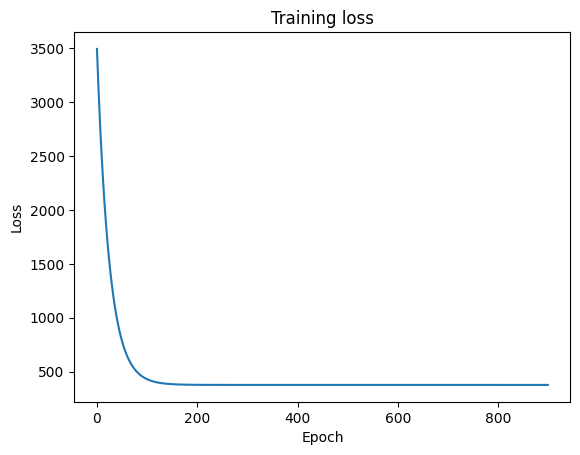

In [104]:
plt.plot(model.first_loss[100:])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

<a id='2'></a>
# 3. Validation :

In [100]:
class black_scholes():
    """ 
    Forward the theorical BS price of an option
    """
    def __init__(
            self,
            S0 : float,
            T : float,
            K : float,
            r : float,
            sigma : float,
    ):
          self.S0 = S0
          self.T = T
          self.K = K
          self.r = r
          self.sigma = sigma

    def price_option(
            self
    ):
            D1 = (1/(self.sigma * np.sqrt(self.T))) * (np.log(self.S0/self.K) + (self.r + ((self.sigma)**2)/2) * self.T)
            D2 = D1 - self.sigma * np.sqrt(self.T)
            return self.S0 * norm.cdf (D1) - self.K * np.exp(-self.r * self.T) * norm.cdf (D2)

In [126]:
####################
### Check rapide ###
####################

# Black Scholes
price_bs = black_scholes(S0=80., T=1., K=100., r=0.02, sigma=0.2)


# DBDP1
model = DBDP1(
    N=10,
    n=100_000,
    S0=80.0,
    T=1.0,
    K=100.0,
    r=0.02,
    sigma=0.2,
    hidden_size=4,
    activation_function="ReLU"
)

price_DBDP_1 = model.train_model(
    lr=1e-1,
    training_iterations=1_000
)


print(f"Prix BS analytique : {price_bs.price_option():.4f}")
print(f"Prix BSDE          : {price_DBDP_1:.4f}")

Prix BS analytique : 1.4274
Prix BSDE          : 1.4077


n = 100 N = 50 p = 5.8
n = 1000 N = 10  p = 5.9

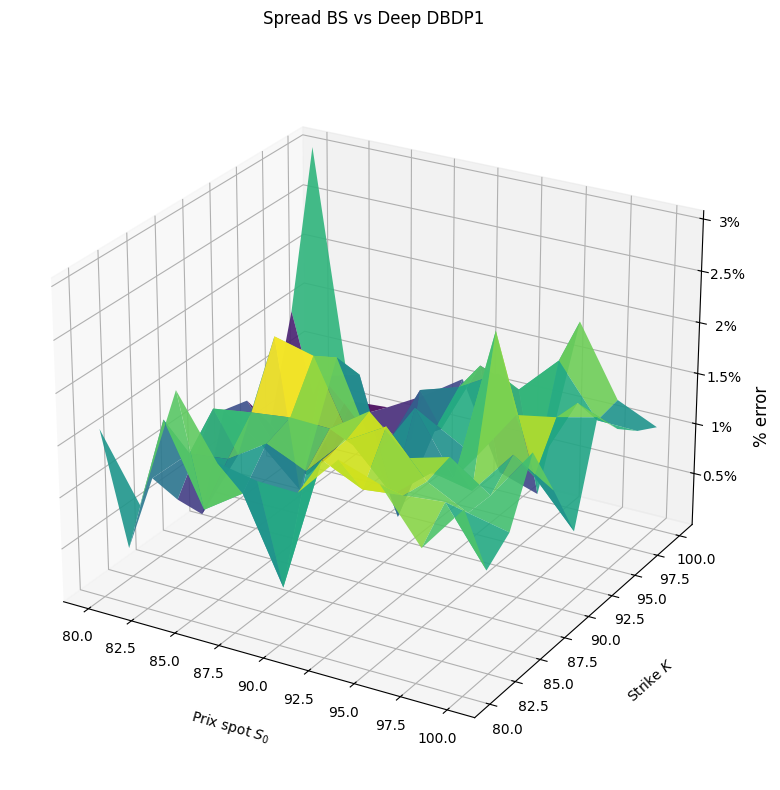

In [ ]:
####################
### Graph report ###
####################
prices = np.linspace(80, 100, 10)
strikes = np.linspace(80, 100, 10)
spread_storage = []

for x in prices:
    for y in strikes:
        price_bs = black_scholes(S0=x, T=1., K=y, r=0.02, sigma=0.2)
        model = DBDP1(N=10, n=100_000, S0=x, T=1.0, K=y, r=0.02, sigma=0.2,
                      hidden_size=4, activation_function="ReLU")
        price_DBDP_1 = model.train_model(lr=1e-1, training_iterations=1_000)
        spread = np.abs((price_bs.price_option() - price_DBDP_1)) / price_bs.price_option()
        spread_storage.append([x, y, spread])

spread_storage = np.array(spread_storage)
S = spread_storage[:, 0].reshape(10, 10)
K = spread_storage[:, 1].reshape(10, 10)
Z = spread_storage[:, 2].reshape(10, 10) * 100  # → en %

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S, K, Z, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('Prix spot $S_0$', labelpad=15)
ax.set_ylabel('Strike $K$', labelpad=20)
ax.set_zlabel('')
ax.zaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3g}%'))
ax.text2D(1.02, 0.5, '% error', transform=ax.transAxes,
          fontsize=12, va='center', rotation=90)

ax.set_title('Spread BS vs Deep DBDP1', pad=20)
ax.view_init(elev=25, azim=-60)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

<a id='3'></a>
# 4. Appendix :

---

<a id='3_1'></a>
### 4.1 Construction of BSDE Scheme :


#### Price PDE :

Under the risk–neutral measure $\mathbb{Q}$, the asset price satisfies:

$$
\partial_t C \;+\; r s\,\partial_s C \;+\; \tfrac12 \sigma^2 s^2\,\partial_{ss}C \;-\; r C \;=\; 0,
\qquad C(s, T)=(s-K)_+ 
$$


$$
\implies
\partial_t C(t,s) + \mathcal{L}C(t,s) = rC,
\qquad \mathcal{L} = r s\,\partial_s + \frac{1}{2}\sigma^2 s^2\,\partial_{ss}
\qquad C(s, T) = (s-K)_+
$$

Hence, in BSDE form, the driver can be identified as
$$
\boxed{
f(y)=r\,y
}
$$

$$
\implies
\partial_t C(t,s) + \mathcal{L}C(t,s) = f(C)
$$

##### Dynamics of $C$ :

Applying Itô's formula to $C(t,S_t)$ gives
$$
dC(t,S_t)
=
\partial_t C(t,S_t)\,dt
+
\partial_s C(t,S_t)\,dS_t
+
\frac{1}{2}\partial_{ss} C(t,S_t)\,d\langle S\rangle_t
=
\left(
\partial_t C
+
rS_t\,\partial_s C
+
\frac{1}{2}\sigma^2 S_t^2\,\partial_{ss} C
\right)(t,S_t)\,dt
+
\sigma S_t\,\partial_s C(t,S_t)\,dW_t.
$$

$$
\implies
dC(t,S_t)
=
\left(
\partial_t C + \mathcal{L}C
\right)(t,S_t)\,dt
+
\sigma S_t\,\partial_s C(t,S_t)\,dW_t.
$$

$$
\implies
dC(t,S_t)
=

f(C)\,dt
+
\sigma S_t\,\partial_s C(t,S_t)\,dW_t.
$$

Defining
$$
Y_t = C(t,S_t),
\qquad
Z_t = \sigma S_t\,\partial_s C(t,S_t),
$$
we finally get
$$
\boxed{
dY_t = f(Y_t)\,dt + Z_t\,dW_t,
\qquad
Y_T = (S_T-K)_+
}
$$

---

<a id='3_2'></a>
### 4.2 Neural network approximation of the process $(Z_t)_{t \ge 0}$


We approximate the control processes $(Y_t)_{t \ge 0}$ and $(Z_t)_{t \ge 0}$ using a family of feedforward neural networks.

Let $i \in \{0,\dots,N-1\}$. For each time step $t_i$, we introduce a neural network

$$
NN_i^j : \mathbb{R}^2 \rightarrow \mathbb{R}
$$

where $j \in \{1,2\}$

More precisely, each neural network is defined as a composition of affine maps and nonlinear activation functions. Let $L \ge 1$ be the number of layers and $(m_\ell)_{\ell=0,\dots,L}$ the layer dimensions, with $m_0 = 2 \quad (t, S_t), \qquad m_L = 1 \quad (Z_t / Y_t).$

The neural network $NN_i^j$ is defined by

$$
NN_i^j(x) = A_L \circ \rho \circ A_{L-1} \circ \dots \circ \rho \circ A_1(x),
\qquad x \in \mathbb{R}^2
$$

where for $\ell = 1,\dots,L$

$$
A_\ell(x) = W_\ell x + b_\ell
$$

are affine transformations with weight matrices $W_\ell$ and bias vectors $b_\ell$, and $\rho : \mathbb{R} \rightarrow \mathbb{R}$ is a nonlinear activation function applied component-wise.

The parameters of the neural network are therefore the collection $\theta_i = (W_\ell, b_\ell)_{\ell=1,\dots,L}.$

Finally we approximate

$$
Z_{t_i} \approx NN_i^1(t_i,S_{t_i};\theta_i)
\qquad
Y_{t_i} \approx NN_i^2(t_i,S_{t_i};\theta_i)
$$